# LAB 1 - MNIST-AE

Implementation and empirical analysis of an defined and trained autoencoder for (a variant of) MNIST digits using Tensorflow and Keras.

References: \
MNIST_AE.ipynb \
Lab 1-MNIST-AE-v2.pdf \
https://www.ibm.com/think/topics/generative-model \
[Andrew Ng — Sparse Autoencoder, Stanford lecture notes](https://web.stanford.edu/class/cs294a/sparseAutoencoder.pdf) \
[Dive into Deep Learning — Weight Decay](https://classic.d2l.ai/chapter_multilayer-perceptrons/weight-decay.html)


October 6, 2026 \
Octavian Popuiac \
a79911@ualg.pt 

## 1. Theoretical responses

### 1 - What is a generative model?

A generative model is a type of machine learning model that learns patterns in the distribution of training data and can generate new samples resembling that data.

For example:
- A **classifier** learns to answer: "Which digit is this image?"
- A **generative model** learns the structure of a digit image so it can produce a new image resembling a handrwite digit.

### 2 — What is the goal of an autoencoder?

The goal of an **autoencoder (AE)** is to learn a useful latent representation of the input by reconstructing it as accurately as possible.

An autoencoder consists of two components:

- The **encoder** maps the input $x_i$ to a latent representation $h$: $$h = g(Wx_i + b).$$
- The **decoder** maps this representation back to a reconstruction $\hat{x}_i$: $$\hat{x}_i = f(W^*h + c).$$

During training, the model learns its weights and biases by minimizing a **reconstruction loss**, which measures the difference between $x_i$ and $\hat{x}_i$. For example, the mean squared error (MSE) is:

$$
\mathcal{L}_{\mathrm{reconstruction}}
= \frac{1}{d}\sum_{j=1}^{d}(x_{ij}-\hat{x}_{ij})^2,
$$

where $d$ is the number of input features, and $j$ indexes those features.

A **bottleneck** is a latent representation with fewer dimensions than the input. It restricts the information passed to the decoder, encouraging the encoder to capture patterns that are useful for reconstruction.

**Regularization** introduces additional constraints or penalties, such as penalizing large weights or encouraging sparse activations. These mechanisms discourage a trivial identity mapping and promote useful representations, although they do not guarantee them. When regularization penalties are used, the training objective includes both the reconstruction loss and those penalties.

The latent representation $h$ is therefore the **code produced by the encoder**, not the complete autoencoder.

![Vanilla autoencoder architecture](./images/vanilla_autoencoder.png)

*Figure 1 — A vanilla autoencoder. The encoder maps the input to a latent representation, and the decoder reconstructs the input from that representation. In this example, the latent layer has four units, compared with five input units.*

The notation used in Figure 1 is summarized in [Table 1](#ae-symbols-table).

<a id="ae-symbols-table"></a>

**Table 1 — Autoencoder symbols**

| Symbol | Meaning |
|---|---|
| $x_i$ | The $i$-th input in the dataset. For MNIST, an image represented by its pixel values. |
| $W$ | The **encoder's weight matrix**, learned during training. Determines how input values are combined. |
| $b$ | The encoder's **bias vector**, learned during training. Shifts the weighted input before the activation function is applied. |
| $g$ | The encoder's activation function, such as ReLU or sigmoid. |
| $h$ | The **latent representation**, or code, produced by the encoder. |
| $W^*$ | The **decoder's weight matrix**, learned during training. The asterisk does not necessarily indicate the inverse or transpose of $W$. |
| $c$ | The decoder's **bias vector**, learned during training. Shifts the weighted latent representation before the output activation function is applied. |
| $f$ | The decoder's activation function. For example, sigmoid produces values between 0 and 1, suitable for normalized pixels. |
| $\hat{x}_i$ | The reconstructed input. The “hat” indicates an estimate of $x_i$. |

### 3 - What’s the point for a complete autoencoder?

A complete autoencoder has a latent representation with the same dimensionality as its input. Without additional constraints, it can learn the identity mapping, simply copying the input without learning useful features.

However, it can still learn useful representations when suitable constraints or training objectives are introduced. For example, sparsity regularization encourages fewer active latent units, while denoising training requires the model to reconstruct a clean input from a corrupted version.

Unlike an undercomplete autoencoder, it does not rely on a smaller latent representation to encourage useful feature learning.

### 4 - Is an autoencoder a supervised or an unsupervised learning method?

An autoencoder is considered an **unsupervised learning method** because it learns from data without requiring external labels.

Instead, the input itself serve as the target, the model learns to reconstruct it by minimizing the difference between the original input and the reconstructed output. For this reason, an autoencoder can be described as **self-supervised learning**.

### 5 — Given the autoencoder, compute $h$ and $\hat{x}^{(i)}$

As introduced in Question 2, the encoder computes the latent representation:

$$
h = g(Wx^{(i)} + b).
$$

The decoder then computes the reconstructed output:

$$
\hat{x}^{(i)} = f(W^*h + c).
$$

Equivalently, the complete mapping is:

$$
\hat{x}^{(i)} = f\left(W^*g(Wx^{(i)} + b) + c\right).
$$

The symbols are defined in [Table 1](#ae-symbols-table).

### 6 — Update expressions for the elements of $W$

We assume that the encoder and decoder have independent weight matrices,
$W$ and $W^*$, and use gradient descent with learning rate $\eta$.

Each encoder weight $W_{jq}$ connects input component $q$ to latent neuron $j$.
Its update is:

$$
W_{jq} \leftarrow W_{jq} - \eta \frac{\partial J}{\partial W_{jq}},
$$

where $J$ is the training objective.

#### Forward propagation and reconstruction loss

For training example $i$:

$$
a^{(i)} = Wx^{(i)} + b,
\qquad
h^{(i)} = g(a^{(i)}),
$$

$$
u^{(i)} = W^*h^{(i)} + c,
\qquad
\hat{x}^{(i)} = f(u^{(i)}).
$$

Here, $a^{(i)}$ and $u^{(i)}$ are the values before the activation functions.

For $N$ training examples and $d$ input components, we define:

$$
J_0 =
\frac{1}{N}\sum_{i=1}^{N}
\frac{1}{2}\sum_{l=1}^{d}
\left(\hat{x}_l^{(i)}-x_l^{(i)}\right)^2.
$$

This loss averages over examples and sums over input components.
The factor $1/2$ simplifies differentiation.

#### i) Vanilla autoencoder

Using the chain rule, the output error signal is:

$$
\delta_{o,l}^{(i)}
=
\left(\hat{x}_l^{(i)}-x_l^{(i)}\right)f'(u_l^{(i)}).
$$

Each latent neuron influences multiple outputs. Therefore, their contributions
are summed when propagating the error back to that neuron:

$$
\delta_{h,j}^{(i)}
=
\left(
\sum_{l=1}^{d} W^*_{lj}\delta_{o,l}^{(i)}
\right)g'(a_j^{(i)}).
$$

The gradient for each encoder weight is:

$$
\frac{\partial J_0}{\partial W_{jq}}
=
\frac{1}{N}\sum_{i=1}^{N}
\delta_{h,j}^{(i)}x_q^{(i)}.
$$

Therefore, the update is:

$$
\boxed{
W_{jq}\leftarrow
W_{jq}
-
\eta\frac{1}{N}\sum_{i=1}^{N}
\delta_{h,j}^{(i)}x_q^{(i)}
}
$$

For example, with two inputs, one latent neuron, and two outputs,
the latent error signal for one example is:

$$
\delta_h =
\left(v_1\delta_{o,1}+v_2\delta_{o,2}\right)g'(a),
$$

where $v_1$ and $v_2$ are the decoder weights. The gradients of the two
encoder weights are then $\delta_h x_1$ and $\delta_h x_2$.

#### ii) Weight-decay regularized autoencoder

We add an L2 penalty to the encoder and decoder weights:

$$
J_{\mathrm{L2}}
=
J_0+
\frac{\lambda}{2}
\left(
\sum_{j,q}W_{jq}^{2}
+
\sum_{l,j}(W^*_{lj})^{2}
\right),
$$

where $\lambda\geq0$ controls the regularization strength.

The derivative of the encoder penalty with respect to $W_{jq}$ is
$\lambda W_{jq}$. Therefore:

$$
\boxed{
W_{jq}\leftarrow
W_{jq}
-
\eta\left[
\frac{1}{N}\sum_{i=1}^{N}
\delta_{h,j}^{(i)}x_q^{(i)}
+
\lambda W_{jq}
\right]
}
$$

Equivalently:

$$
W_{jq}\leftarrow
(1-\eta\lambda)W_{jq}
-
\eta\frac{1}{N}\sum_{i=1}^{N}
\delta_{h,j}^{(i)}x_q^{(i)}.
$$

The additional term encourages smaller weight magnitudes. This equivalence
between L2 regularization and weight decay applies to the gradient-descent
update used here.

#### iii) Sparse autoencoder

For this case, we choose a KL-divergence sparsity penalty and assume
sigmoid latent activations.

Let $\rho\in(0,1)$ be a small desired mean activation, and let:

$$
\hat{\rho}_j =
\frac{1}{N}\sum_{i=1}^{N}h_j^{(i)}
$$

be the observed mean activation of latent neuron $j$.

The objective is:

$$
J_{\mathrm{sparse}}
=
J_0+\beta\sum_j\mathrm{KL}(\rho\|\hat{\rho}_j),
$$

where $\beta\geq0$ controls the strength of the sparsity penalty and:

$$
\mathrm{KL}(\rho\|\hat{\rho}_j)
=
\rho\log\frac{\rho}{\hat{\rho}_j}
+
(1-\rho)\log\frac{1-\rho}{1-\hat{\rho}_j}.
$$

Its derivative with respect to $\hat{\rho}_j$ is:

$$
-\frac{\rho}{\hat{\rho}_j}
+
\frac{1-\rho}{1-\hat{\rho}_j}.
$$

Consequently, the latent error signal becomes:

$$
\delta_{h,j}^{\mathrm{sparse},(i)}
=
\left[
\sum_{l=1}^{d}W^*_{lj}\delta_{o,l}^{(i)}
+
\beta\left(
-\frac{\rho}{\hat{\rho}_j}
+
\frac{1-\rho}{1-\hat{\rho}_j}
\right)
\right]g'(a_j^{(i)}).
$$

The encoder weight update is:

$$
\boxed{
W_{jq}\leftarrow
W_{jq}
-
\eta\frac{1}{N}\sum_{i=1}^{N}
\delta_{h,j}^{\mathrm{sparse},(i)}x_q^{(i)}
}
$$

This penalty encourages each latent neuron's mean activation to approach
the small target $\rho$, promoting sparse representations.

If L2 and KL sparsity penalties are combined, an additional
$\lambda W_{jq}$ term is included in the gradient.

#### Connection to the experiments

The experiments use L1 regularization on latent activations instead of KL.
For the penalty:

$$
J_{\mathrm{L1}}
=
J_0+\frac{\beta}{N}\sum_{i,j}|h_j^{(i)}|,
$$

the corresponding latent error signal is:

$$
\delta_{h,j}^{\mathrm{L1},(i)}
=
\left[
\sum_l W^*_{lj}\delta_{o,l}^{(i)}
+
\beta\,\operatorname{sign}(h_j^{(i)})
\right]g'(a_j^{(i)}).
$$

At zero, we choose the subgradient zero.

The derivations above use gradient descent and half the sum of squared
reconstruction errors per example. The notebook uses Adam and a mean squared
error over pixels, so its optimizer updates and loss scaling differ.

All gradients for a training step are computed using the parameters
before that step's updates.


## 2. Empirical analysis

This section investigates how the depth of an autoencoder and the use of regularization affect its ability to reconstruct MNIST images.

We compare three architectures with one, two, and three hidden layers in the encoder and a symmetric decoder. This count excludes the latent layer and the output layer. The latent representation is fixed at two dimensions.

Each architecture is evaluated under three conditions:

- **No regularization:** a baseline using only reconstruction loss.
- **L1 regularization on latent activations:** encourages sparse representations.
- **L2 regularization on weights:** penalizes large weight magnitudes.

This produces nine configurations. Each configuration is trained with three random seeds (42, 123, and 2026), resulting in 27 training runs.

The original MNIST training set is split into 50,000 training images and 10,000 validation images. The official 10,000 test images are kept separate. Pixel values are normalized to the range [0, 1], and the same data split is used for all experiments.

All models use Adam with a learning rate of 0.001, a batch size of 128, and a maximum of 30 epochs. Early stopping monitors validation MSE with a patience of five epochs and restores the best weights.

We compare reconstruction MSE, the difference between validation and training MSE, training time, parameter count, and latent activation sparsity. Learning curves and reconstructed images provide additional evidence of model behavior. Reconstruction MSE is reported separately from regularization penalties to allow a consistent comparison.

The configuration with the lowest mean validation MSE across seeds is selected for evaluation on the test set. Its latent space is also visualized to explore how images are represented and decoded.

In [20]:
import os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEEDS = [42, 123, 2026]
EPOCHS = 30
BATCH_SIZE = 128
LATENT_DIM = 2
LAMBDA_L2 = 1e-5
BETA_L1 = 1e-4
OUT = Path("resultados_tp1")
OUT.mkdir(exist_ok=True)

try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

TensorFlow: 2.21.0
GPU: []


x_train: (50000, 28, 28, 1)
x_val:   (10000, 28, 28, 1)
x_test:  (10000, 28, 28, 1)


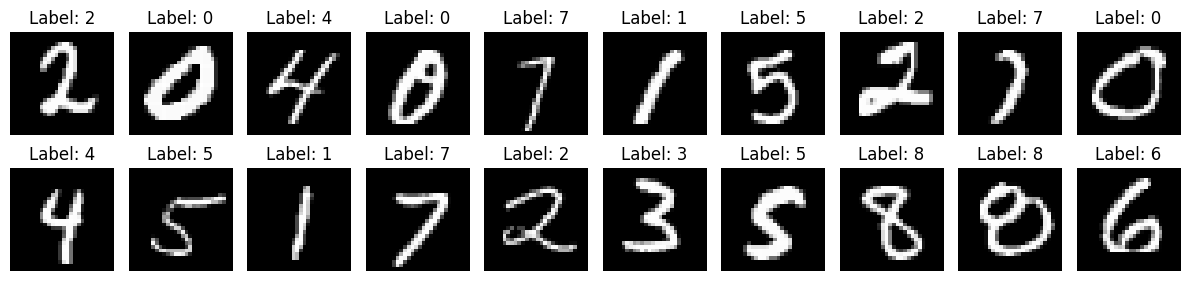

In [21]:
(x_train, y_train), (x_test, _) = keras.datasets.mnist.load_data()

rng = np.random.default_rng(2026)
idx = rng.permutation(len(x_train))

n_train = 50000
train_idx, val_idx = idx[:n_train], idx[n_train:]

def normalize(x):
  return x.astype("float32")[..., None] / 255.0

x_train, x_val, x_test = map(normalize, [x_train[train_idx], x_train[val_idx], x_test])
y_train, y_val = y_train[train_idx], y_train[val_idx]

assert x_train.shape[1:] == (28, 28, 1)
assert len(x_val) > 0

print(f"x_train: {x_train.shape}")  # (50000, 28, 28, 1)
print(f"x_val:   {x_val.shape}")    # (10000, 28, 28, 1)
print(f"x_test:  {x_test.shape}")   # (10000, 28, 28, 1)

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
  ax.imshow(x_train[i, ..., 0], cmap='gray')
  ax.set_title(f"Label: {y_train[i]}")
  ax.axis('off')
plt.tight_layout()
plt.show()

### 1. Model

Implemented a fully connected autoencoder consisting of an **encoder** and a **decoder**.

The encoder flattens each input image from shape $(28, 28, 1)$ into a vector of 784 pixel values. It then applies a sequence of Dense layers with ReLU activations, followed by a two-dimensional latent layer, also using ReLU.

The decoder takes the latent representation and applies Dense layers in the reverse order of the encoder's hidden layers. Its final Dense layer contains 784 units with sigmoid activation, producing values between 0 and 1. The output is then reshaped to $(28, 28, 1)$.

The following architectures are compared:

| Encoder depth | Encoder | Decoder |
|---|---|---|
| 1 hidden layer | 784 → 128 → 2 | 2 → 128 → 784 |
| 2 hidden layers | 784 → 256 → 128 → 2 | 2 → 128 → 256 → 784 |
| 3 hidden layers | 784 → 256 → 128 → 64 → 2 | 2 → 64 → 128 → 256 → 784 |

The depth count excludes the latent layer and the output layer.
All three architectures are **undercomplete**, since the latent dimension is smaller than the input dimension.

The `build_ae(depth, reg)` function creates the selected architecture and returns the complete autoencoder, the encoder, and the decoder. Each architecture supports three regularization settings:

- **None:** no additional regularization penalty.
- **L1:** the custom `SparsePenalty` layer penalizes the absolute latent activations, using `BETA_L1 = 1e-4`.
- **L2:** all Dense-layer weight matrices are penalized using `LAMBDA_L2 = 1e-5`, with a coefficient of `LAMBDA_L2 / 2` to match the theoretical penalty $\frac{\lambda}{2}\sum w^2$. Biases are not penalized.

The model is compiled with the Adam optimizer and MSE reconstruction loss.
MSE is also tracked as a separate metric so that reconstruction performance can be compared independently of the regularization penalties.

In [22]:
@keras.utils.register_keras_serializable(package="TP1")
class SparsePenalty(layers.Layer):
  def __init__(self, beta=0.0, **kwargs):
    super().__init__(**kwargs)
    self.beta = beta

  def call(self, inputs):
    self.add_loss(self.beta * tf.reduce_mean(tf.reduce_sum(tf.abs(inputs), axis=1)))
    return inputs

  def get_config(self):
    return {**super().get_config(), "beta": self.beta}

In [23]:
ARCHS = {1: [128], 2: [256, 128], 3: [256, 128, 64]}

def build_ae(depth, reg):
  widths = ARCHS[depth]
  penalty = keras.regularizers.l2(LAMBDA_L2 / 2) if reg == "l2" else None
  inp = keras.Input((28,28,1))
  h = layers.Flatten()(inp)

  for width in widths:
    h = layers.Dense(width, activation="relu", kernel_regularizer=penalty)(h)

  z = layers.Dense(LATENT_DIM, activation="relu", kernel_regularizer=penalty, name="latent")(h)

  if reg == "l1":
    z = SparsePenalty(beta=BETA_L1)(z)

  encoder = keras.Model(inp, z, name="encoder")
  zin = keras.Input((LATENT_DIM,))
  h = zin

  for width in reversed(widths):
    h = layers.Dense(width, activation="relu", kernel_regularizer=penalty)(h)

  h = layers.Dense(28*28, activation="sigmoid", kernel_regularizer=penalty)(h)
  out = layers.Reshape((28,28,1))(h)

  decoder = keras.Model(zin, out, name="decoder")
  ae = keras.Model(inp, decoder(encoder(inp)), name="autoencoder")
  ae.compile(
    optimizer=keras.optimizers.Adam(1e-3), 
    loss="mse",
    metrics=[keras.metrics.MeanSquaredError(name="mse")],
  )

  return ae, encoder, decoder

model, encoder, decoder = build_ae(2, "none")

assert tuple(model.output_shape[1:]) == (28, 28, 1)

model.summary()
encoder.summary()
decoder.summary()

del model, encoder, decoder

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       234,114 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       234,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,010 (1.79 MB)

 Trainable params: 469,010 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

### 2. Train

Each combination of encoder depth and regularization is trained using three random seeds: 42, 123, and 2026. This results in 27 training runs.

The autoencoder receives the same images as inputs and targets, learning to reconstruct them. Training uses:

- **Optimizer:** Adam with a learning rate of 0.001.
- **Batch size:** 128.
- **Maximum epochs:** 30.
- **Shuffling:** training samples are shuffled each epoch.
- **Early stopping:** training stops after five epochs without improvement in validation MSE, and the weights with the best validation MSE are restored.

After each run, the model is evaluated on the training and validation sets.
We record reconstruction MSE, the validation–training MSE gap, training time, parameter count, and the fraction of latent activations with absolute values below $10^{-6}$. 

In [24]:
rows, histories = [], {}

for depth in ARCHS:
  for reg in ["none", "l1", "l2"]:
    for seed in SEEDS:
      print(f"Training AE with depth={depth}, reg={reg}, seed={seed}...")
      keras.backend.clear_session()
      keras.utils.set_random_seed(seed)

      model, encoder, decoder = build_ae(depth, reg)
      run = f"depth={depth}_reg={reg}_seed={seed}"
      start = time.perf_counter()

      history = model.fit(
        x_train, x_train,
        validation_data=(x_val, x_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_mse", mode="min", patience=5, restore_best_weights=True)],
      )

      elapsed = time.perf_counter() - start

      train_eval = model.evaluate(x_train, x_train, verbose=0, return_dict=True)
      val_eval = model.evaluate(x_val, x_val, verbose=0, return_dict=True)
      z = encoder.predict(x_val, verbose=0)

      checkpoint = OUT / f"{run}.weights.h5"
      model.save_weights(checkpoint)

      histories[run] = history.history
      rows.append(
        dict(
          run=run,
          depth=depth,
          regularization=reg,
          seed=seed,
          params=model.count_params(),
          epochs=len(history.history["loss"]),
          seconds=elapsed,
          train_mse=train_eval["mse"],
          val_mse=val_eval["mse"],
          gap=val_eval["mse"] - train_eval["mse"],
          latent_zero_fraction=float(np.mean(np.abs(z) < 1e-6)),
        )
      )
      pd.DataFrame(rows).to_csv(OUT / "runs.csv", index=False)
      with open(OUT / "histories.json", "w") as file:
        json.dump(histories, file, indent=2)

results = pd.DataFrame(rows)
summary = results.groupby(["depth", "regularization"]).agg(
  val_mse_mean=("val_mse", "mean"), 
  val_mse_std=("val_mse", "std"),
  train_mse_mean=("train_mse", "mean"),
  gap_mean=("gap", "mean"),
  params=("params", "first"), 
  seconds_mean=("seconds", "mean"),
  sparsity_mean=("latent_zero_fraction", "mean")
).reset_index()

summary = summary.sort_values(["val_mse_mean"])
display(summary)

Training AE with depth=1, reg=none, seed=42...
Epoch 1/30
391/391 - 5s - 13ms/step - loss: 0.0694 - mse: 0.0694 - val_loss: 0.0577 - val_mse: 0.0577
Epoch 2/30
391/391 - 3s - 8ms/step - loss: 0.0549 - mse: 0.0549 - val_loss: 0.0528 - val_mse: 0.0528
Epoch 3/30
391/391 - 4s - 10ms/step - loss: 0.0516 - mse: 0.0516 - val_loss: 0.0508 - val_mse: 0.0508
Epoch 4/30
391/391 - 4s - 10ms/step - loss: 0.0499 - mse: 0.0499 - val_loss: 0.0493 - val_mse: 0.0493
Epoch 5/30
391/391 - 3s - 8ms/step - loss: 0.0487 - mse: 0.0487 - val_loss: 0.0483 - val_mse: 0.0483
Epoch 6/30
391/391 - 3s - 8ms/step - loss: 0.0477 - mse: 0.0477 - val_loss: 0.0474 - val_mse: 0.0474
Epoch 7/30
391/391 - 5s - 12ms/step - loss: 0.0470 - mse: 0.0470 - val_loss: 0.0469 - val_mse: 0.0469
Epoch 8/30
391/391 - 3s - 9ms/step - loss: 0.0464 - mse: 0.0464 - val_loss: 0.0464 - val_mse: 0.0464
Epoch 9/30
391/391 - 3s - 8ms/step - loss: 0.0460 - mse: 0.0460 - val_loss: 0.0461 - val_mse: 0.0461
Epoch 10/30
391/391 - 3s - 8ms/step - lo

,depth,regularization,val_mse_mean,val_mse_std,train_mse_mean,gap_mean,params,seconds_mean,sparsity_mean
8,3,none,0.036497,0.000585,0.035795,0.000702,485266,231.171402,0.007350
6,3,l1,0.037327,0.000612,0.036787,0.000540,485266,226.811297,0.012667
5,2,none,0.038057,0.000192,0.036603,0.001453,469010,216.890816,0.006833
7,3,l2,0.038222,0.000823,0.037687,0.000534,485266,243.451352,0.005333
2,1,none,0.043256,0.000367,0.042501,0.000755,202258,120.335751,0.015150
0,1,l1,0.044345,0.000789,0.043645,0.000700,202258,119.730114,0.031183
1,1,l2,0.044656,0.000638,0.044305,0.000350,202258,130.752919,0.034550
3,2,l1,0.048258,0.016420,0.047769,0.000489,469010,219.650310,0.343350
4,2,l2,0.048972,0.015827,0.048607,0.000365,469010,239.589032,0.338417


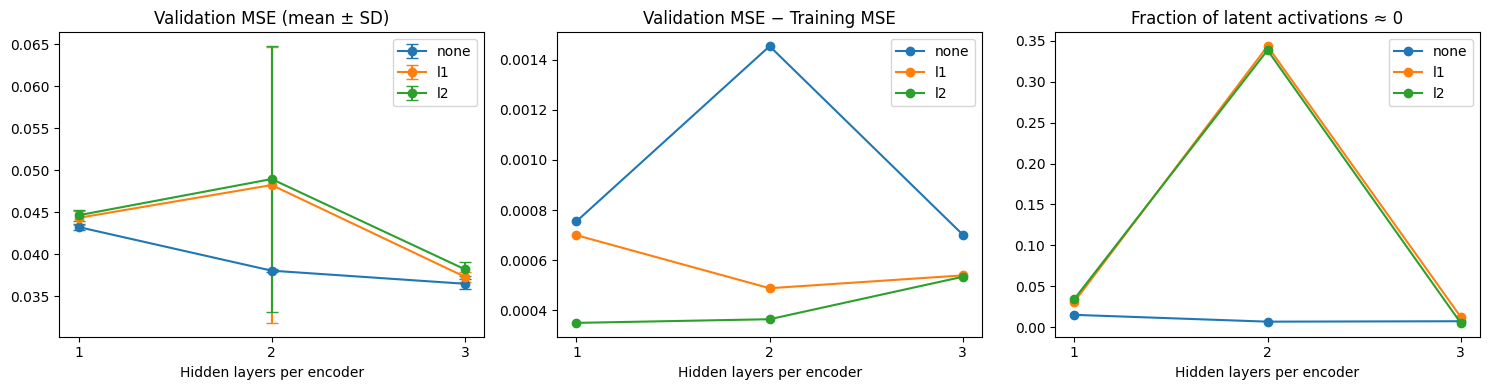

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for reg in ["none", "l1", "l2"]:
  s = summary[summary.regularization == reg].sort_values("depth")
  axes[0].errorbar(
    s.depth, s.val_mse_mean,
    yerr=s.val_mse_std.fillna(0),
    marker="o", capsize=4, label=reg
  )
  axes[1].plot(s.depth, s.gap_mean, marker="o", label=reg)
  axes[2].plot(s.depth, s.sparsity_mean, marker="o", label=reg)

titles = [
  "Validation MSE (mean ± SD)",
  "Validation MSE − Training MSE",
  "Fraction of latent activations ≈ 0"
]

for ax, title in zip(axes, titles):
  ax.set_title(title)
  ax.set_xlabel("Hidden layers per encoder")
  ax.set_xticks([1, 2, 3])
  ax.legend()

plt.tight_layout()
plt.savefig(OUT / "comparison.png", dpi=150)
plt.show()

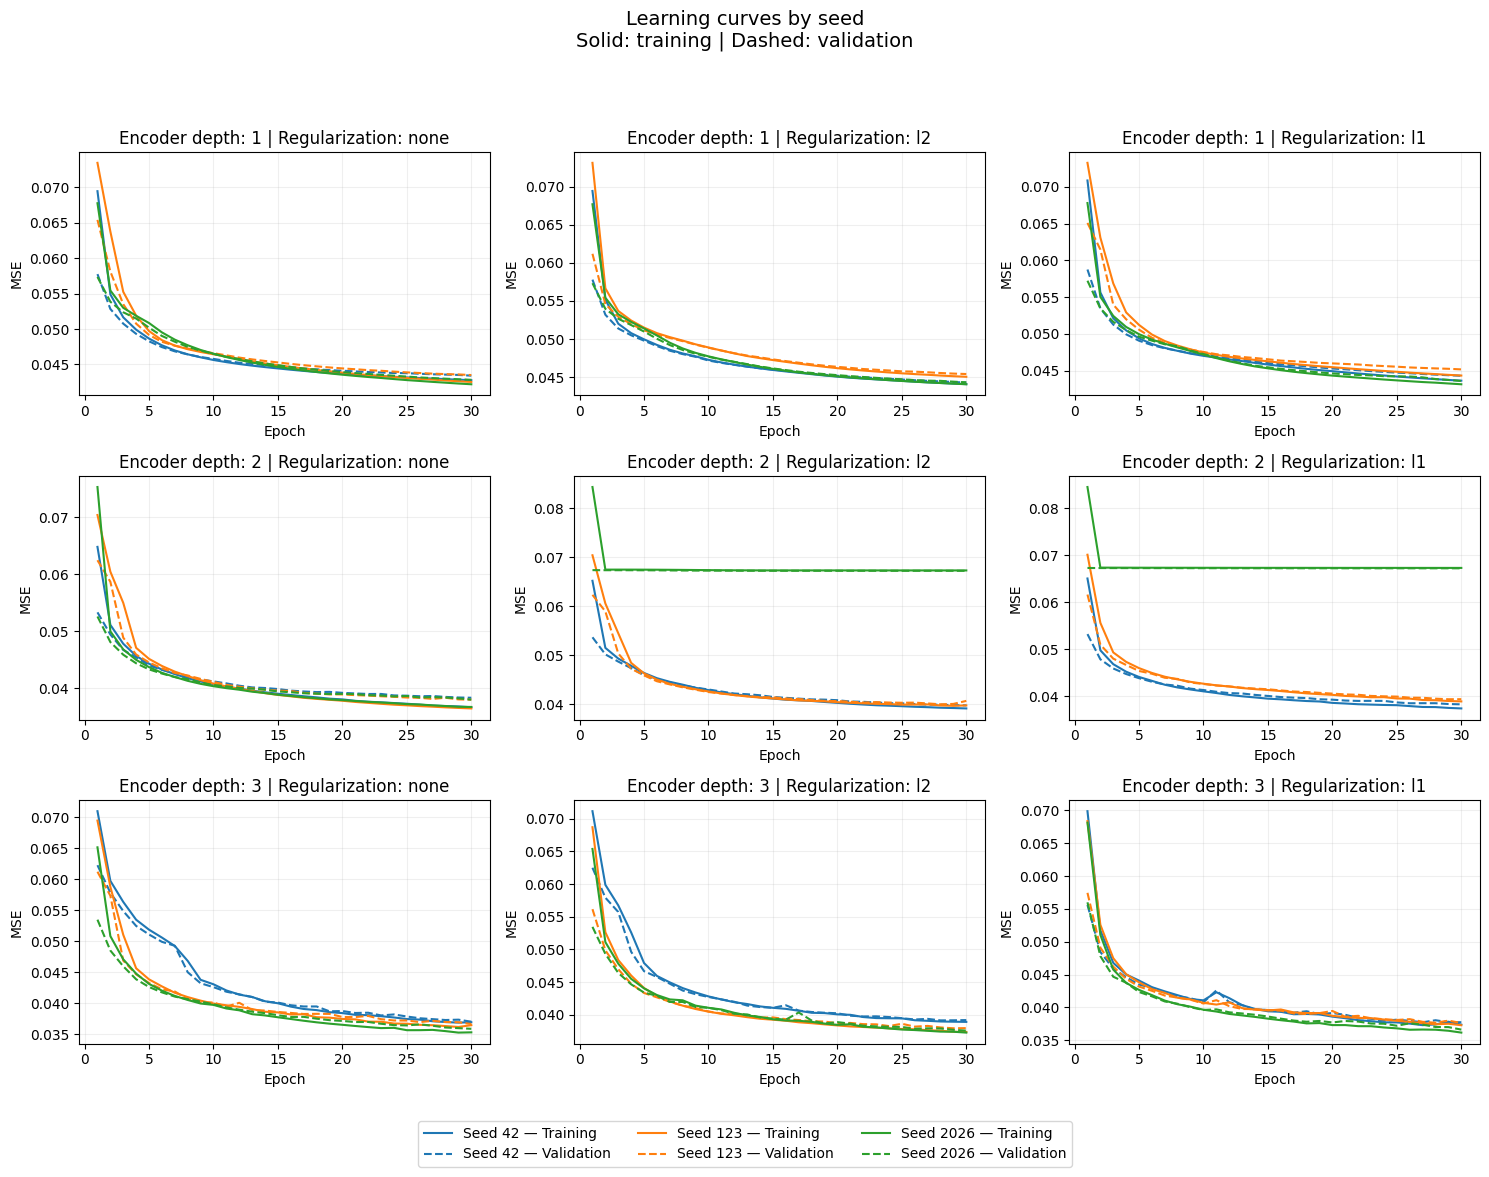

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for row, depth in enumerate(ARCHS):
  for col, reg in enumerate(["none", "l2", "l1"]):
    ax = axes[row, col]

    for seed_idx, seed in enumerate(SEEDS):
      h = histories[f"depth={depth}_reg={reg}_seed={seed}"]
      epochs = range(1, len(h["mse"]) + 1)
      color = f"C{seed_idx}"

      ax.plot(
        epochs, h["mse"],
        color=color, linestyle="-",
        label=f"Seed {seed} — Training"
      )
      ax.plot(
        epochs, h["val_mse"],
        color=color, linestyle="--",
        label=f"Seed {seed} — Validation"
      )

    ax.set_title(f"Encoder depth: {depth} | Regularization: {reg}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.grid(alpha=0.2)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", ncol=len(SEEDS),
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Learning curves by seed\n"
    "Solid: training | Dashed: validation",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.savefig(OUT / "learning_curves.png", dpi=150)
plt.show()

### 3. Final Avaliation

The configuration with the lowest mean validation MSE is evaluated on the test set for each random seed. The mean and standard deviation of test MSE are reported to assess reconstruction performance and consistency across runs.

Original test images are displayed alongside their reconstructions using the first seed in sorted order, providing a visual assessment of reconstruction quality.

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Selected configuration: encoder depth = 3, regularization = none


,seed,test_mse
0,42,0.036745
1,123,0.036413
2,2026,0.035895


Mean test MSE: 0.03635087609291077
Test MSE standard deviation: 0.00042819736610239244


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


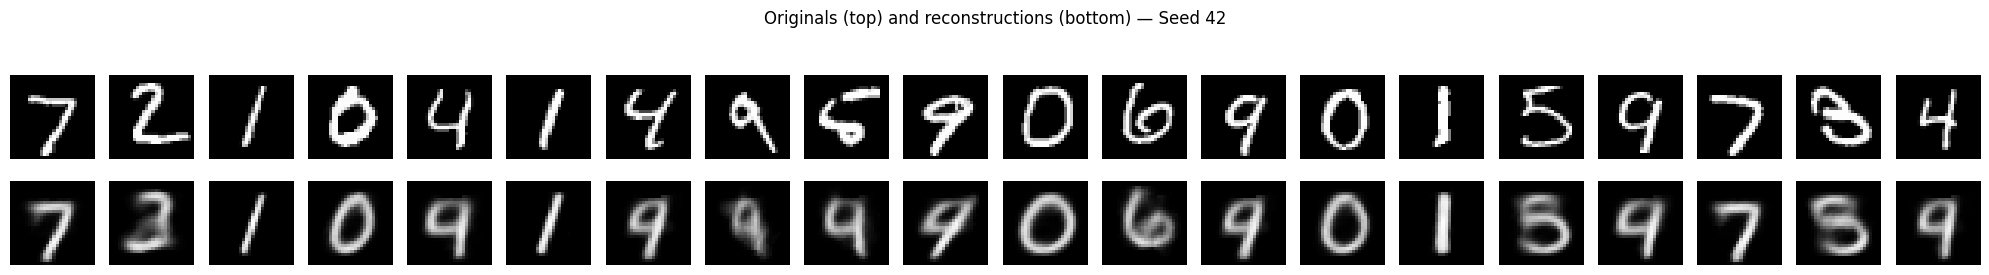

In [ ]:
best = summary.sort_values("val_mse_mean").iloc[0]

# Retrieve all seed runs for the selected configuration
chosen = results[
  (results.depth == best.depth)
  & (results.regularization == best.regularization)
].sort_values("seed")

test_rows = []

for _, row in chosen.iterrows():
  ae, enc, dec = build_ae(int(row.depth), row.regularization)

  checkpoint = OUT / f"{row.run}.weights.h5"
  ae.load_weights(checkpoint)

  # Use the input images as reconstruction targets
  metrics = ae.evaluate(
    x_test, x_test,
    verbose=0,
    return_dict=True
  )

  test_rows.append({
    "seed": int(row.seed),
    "test_mse": metrics["mse"]
  })

test_results = pd.DataFrame(test_rows)
test_results.to_csv(OUT / "selected_test.csv", index=False)

print(
  "Selected configuration:",
  f"encoder depth = {int(best.depth)},",
  f"regularization = {best.regularization}"
)

display(test_results)

print("Mean test MSE:", test_results.test_mse.mean())
print("Test MSE standard deviation:", test_results.test_mse.std())

# Use the first seed in sorted order for visualization
row = chosen.iloc[0]
ae, enc, dec = build_ae(int(row.depth), row.regularization)
ae.load_weights(OUT / f"{row.run}.weights.h5")

recon = ae.predict(x_test[:20], verbose=0)

fig, axes = plt.subplots(2, 20, figsize=(20, 3))

for i in range(20):
  axes[0, i].imshow(
    x_test[i, ..., 0],
    cmap="gray", vmin=0, vmax=1
  )
  axes[1, i].imshow(
    recon[i, ..., 0],
    cmap="gray", vmin=0, vmax=1
  )

  for ax in axes[:, i]:
    ax.axis("off")

fig.suptitle(
  f"Originals (top) and reconstructions (bottom) — Seed {int(row.seed)}"
)

plt.tight_layout()
plt.savefig(OUT / "reconstructions.png", dpi=150)
plt.show()

### 4. Latent Space and Image Synthesis

Validation images are encoded into two-dimensional latent representations and plotted with colors indicating their digit labels. This visualization shows how different digits are organized in the latent space.

A grid of 100 latent points, spanning the 1st to 99th percentiles of each dimension, is decoded into images to explore how the output changes across the latent space. Some points may produce unclear digits, since a standard autoencoder does not guarantee realistic outputs for arbitrary latent codes.

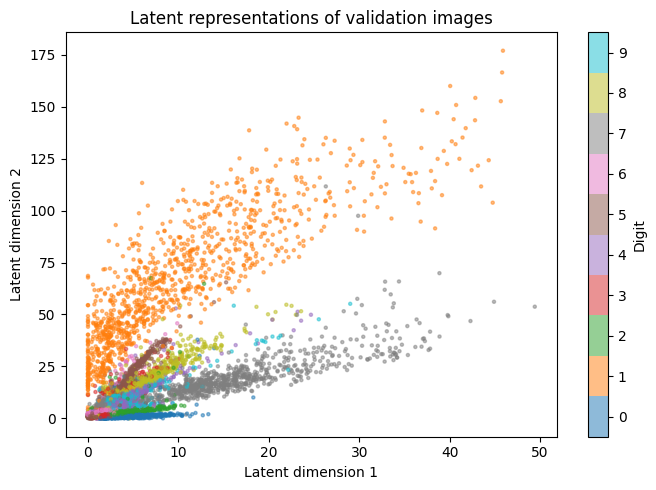

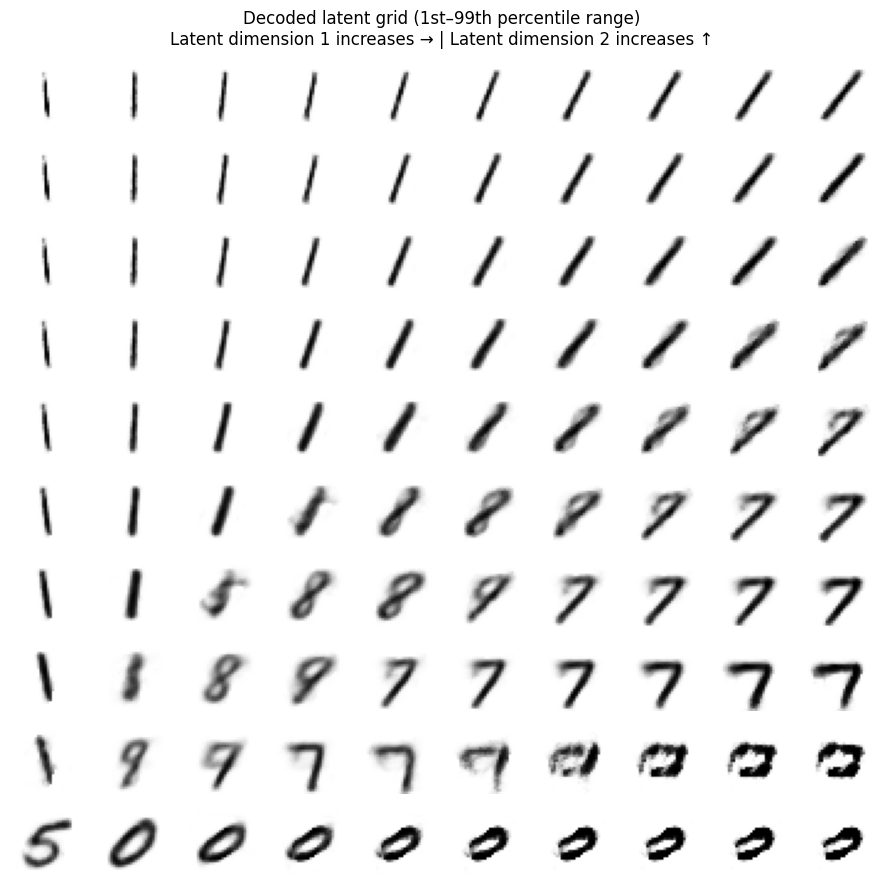

In [28]:
# Encode validation images into two-dimensional latent representations
z = enc.predict(x_val, verbose=0)

fig, ax = plt.subplots(figsize=(7, 5))

p = ax.scatter(
  z[:, 0], z[:, 1],
  c=y_val,
  cmap="tab10",
  s=5,
  alpha=0.5,
  vmin=-0.5,
  vmax=9.5
)

fig.colorbar(p, ticks=range(10), label="Digit")

ax.set(
  xlabel="Latent dimension 1",
  ylabel="Latent dimension 2",
  title="Latent representations of validation images"
)

plt.tight_layout()
plt.savefig(OUT / "latent.png", dpi=150)
plt.show()

# Define a plotting range using the 1st and 99th percentiles
# of each latent dimension
lo, hi = np.percentile(z, [1, 99], axis=0)

# Create a grid of 100 latent coordinates
gx, gy = np.meshgrid(
  np.linspace(lo[0], hi[0], 10),
  np.linspace(hi[1], lo[1], 10)
)

grid = np.column_stack([
  gx.ravel(),
  gy.ravel()
]).astype("float32")

# Decode the grid coordinates into images
generated_images = dec.predict(grid, verbose=0)

fig, axes = plt.subplots(10, 10, figsize=(9, 9))

for ax, img in zip(axes.flat, generated_images):
  ax.imshow(
      img[..., 0],
      cmap="gray_r",
      vmin=0,
      vmax=1
  )
  ax.axis("off")

fig.suptitle(
  "Decoded latent grid (1st–99th percentile range)\n"
  "Latent dimension 1 increases → | Latent dimension 2 increases ↑"
)

plt.tight_layout()
plt.savefig(OUT / "latent_grid.png", dpi=150)
plt.show()

### 5. Discussion

#### Effect of depth

Without regularization, increasing encoder depth consistently reduced mean validation MSE: from 0.043256 with one hidden layer to 0.038057 with two and 0.036497 with three. The deepest architecture achieved approximately 15.6% lower validation MSE than the shallowest model.

The learning curves show improvements across all three seeds for the unregularized architectures. However, the effect of depth was not monotonic under L1 or L2 regularization:

| Encoder depth | No regularization | L1 | L2 |
|---|---|---|---|
| 1 | 0.043256 ± 0.000367 | 0.044345 ± 0.000789 | 0.044656 ± 0.000638 |
| 2 | 0.038057 ± 0.000192 | 0.048258 ± 0.016420 | 0.048972 ± 0.015827 |
| 3 | 0.036497 ± 0.000585 | 0.037327 ± 0.000612 | 0.038222 ± 0.000823 |

Values represent mean validation MSE ± sample standard deviation across three seeds.

The poor average performance of the two-layer regularized models is strongly influenced by seed 2026. For both L1 and L2, this run remained near an MSE of 0.067 throughout most of training, while the other seeds continued improving. This indicates sensitivity to initialization and training dynamics rather than a uniform deterioration across all runs.

#### Model size and training cost

Increasing depth also increased model capacity. The parameter count rose from 202,258 for one hidden layer to 469,010 for two and 485,266 for three.

Compared with the two-layer model, the three-layer model reduced validation MSE by approximately 4.1%, with a relatively small increase in parameters and training time. This was a favorable trade-off within the tested configurations.
However, the improvement cannot be attributed to depth alone because layer widths and parameter counts also changed.

#### Regularization and training stability

For the coefficients tested, neither L1 nor L2 improved mean validation MSE relative to the unregularized model at the same depth.

Regularization reduced the mean validation–training MSE gap. For example, at depth three, the gap decreased from 0.000702 without regularization to 0.000540 with L1 and 0.000534 with L2. However, both regularized models had higher training and validation MSE. A smaller gap therefore did not translate into better reconstruction performance on validation data.

The largest mean gap was 0.001453 for the two-layer unregularized model.
Overall, the gaps were small relative to reconstruction MSE, providing limited evidence of severe overfitting within the training budget.

L1 increased the fraction of near-zero latent activations compared with the unregularized model at every depth. At depth one, this fraction increased from approximately 1.52% to 3.12%, at depth three, it increased from 0.74% to 1.27%. These increases came with slightly worse reconstruction MSE.

At depth two, the mean near-zero fraction reached approximately 34.34% with L1 and 33.84% with L2. Together with the stalled seed-2026 learning curves, these values suggest a possible latent-unit inactivity problem. However, per-seed activation statistics would be needed to confirm the mechanism.
A high near-zero fraction alone should not be interpreted as a successful sparse representation.

#### Test performance

The three-layer model without regularization was selected using mean validation MSE. Its test results were:

| Seed | Test MSE |
|---|---|
| 42 | 0.036745 |
| 123 | 0.036413 |
| 2026 | 0.035895 |

Mean test MSE was **0.036351 ± 0.000428**, close to the mean validation MSE of 0.036497. This suggests that the selected configuration maintained similar reconstruction performance on the held-out test set.

The reported standard deviation describes variation across training seeds.

#### Reconstruction quality

The reconstruction figure for seed 42 shows that several examples of digits such as 0, 1, and 7 retain recognizable shapes. However, reconstructed images are generally smoother and blurrier than the originals.

Some examples lose distinguishing details: several 4s become similar to 9s, and the displayed 2 becomes more similar to a 3. These are qualitative observations from the displayed images, not class-level error estimates.

The two-dimensional bottleneck restricts the information available to the decoder, while pixel-wise MSE does not directly measure whether digit identity is preserved. Consequently, a relatively low MSE does not guarantee a semantically correct reconstruction.

#### Latent space and synthesis

The latent-space plot shows a structured but overlapping representation.
Digit 1 occupies a relatively distinct region, while several other classes overlap near the lower part of the plot. For the displayed model, the representation is not collapsed to a single point, although the occupied space is unevenly distributed.

The decoded grid shows gradual changes in stroke orientation and digit shape, but many positions produce similar digits or ambiguous images. Large regions are dominated by shapes resembling 1 or 7.

Reconstruction uses the code obtained by encoding a particular image.
Grid-based synthesis instead decodes coordinates selected manually, which may fall in regions with few or no observed latent codes. The percentile bounds limit extreme coordinates but do not guarantee that every grid point represents a plausible digit.

#### Conclusion and limitations

The three-layer autoencoder without regularization achieved the lowest mean validation MSE (0.036497) and a similar mean test MSE (0.036351).
At the tested strengths, L1 and L2 did not improve validation reconstruction performance, although they reduced the training–validation gap.

These conclusions are limited to three seeds, one coefficient per regularization type, a two-dimensional latent space, and a maximum of 30 epochs.
Since depth and parameter count changed together, the improvement cannot be attributed to depth alone.